# 1. 손수 설계하는 선형회귀, 당뇨병 수치를 맞춰보자!

In [2]:
from sklearn.datasets import load_diabetes

# 1. 사이킷런의 내장 데이터셋인 '당뇨병 데이터'를 불러와서 data 변수에 담습니다.
# 이 데이터에는 442명의 환자에 대한 10가지 특성(나이, BMI, 혈압 등)이 들어있습니다.
data = load_diabetes()

# 2. 모델이 학습할 '입력 데이터(특성)'들을 df_X에 저장합니다. 
# 442행 10열의 행렬 형태 데이터입니다.
df_X = data.data

# 3. 모델이 맞춰야 할 '정답(타겟) 데이터'를 df_y에 저장합니다.
# 1년 뒤 당뇨병의 진행도를 수치화한 값입니다.
df_y = data.target

In [3]:
import numpy as np

# 1. 사이킷런 데이터(df_X)를 넘파이 배열(numpy array)로 변환합니다.
# 넘파이 배열은 다차원 행렬 연산에 최적화되어 있어 머신러닝의 '필수 재료'입니다.
X = np.array(df_X)

# 2. 데이터의 타입과 내부 요소의 자료형(dtype)을 확인합니다.
# 여기서 <class 'numpy.ndarray'>와 'float64'(실수형)가 나와야 
# 나중에 소수점 단위의 미세한 가중치(W) 업데이트가 가능해집니다. (매우 중요!)
print(type(X), X.dtype)

<class 'numpy.ndarray'> float64


In [4]:
# 1. 정답 데이터(df_y)를 넘파이 배열(numpy array)로 변환합니다.
# 모델이 예측한 값(prediction)과 이 y값을 비교해서 '얼마나 틀렸는지' 계산하게 됩니다.
y = np.array(df_y)

# 2. 자료형 확인: <class 'numpy.ndarray'>와 'float64'가 출력되는지 체크합니다.
# 계산의 정밀도를 위해 소수점 데이터를 온전히 보존하는 것이 중요합니다.
print(type(y), y.dtype)

<class 'numpy.ndarray'> float64


In [5]:
from sklearn.model_selection import train_test_split

# 1. 사이킷런의 train_test_split을 사용하여 데이터를 나눕니다.
# test_size=0.2: 전체 442개 데이터 중 20%(약 89개)를 테스트용으로, 80%(약 353개)를 학습용으로 배분합니다.
# random_state=42: 데이터를 섞을 때 '난수 고정값'을 주어, 나중에 다시 실행해도 똑같은 데이터셋이 나오게 합니다. (결과 재현성 확보!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. 분리된 데이터의 크기(Shape)를 확인합니다.
# 학습용: (353, 10), (353,) -> 이 데이터로 W와 b를 최적화합니다.
print(X_train.shape, y_train.shape)
# 테스트용: (89, 10), (89,) -> 이 데이터로 최종 MSE 3000 이하인지 시험을 봅니다!
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


In [6]:
# 1. 가중치(W)와 편향(b) 초기화
# X_train.shape[1]은 10입니다. 10개의 특성에 각각 곱해질 10개의 무작위 숫자를 만듭니다.
W = np.random.rand(X_train.shape[1])
# b는 전체 식의 높낮이를 조절하는 상수로, 딱 1개만 있으면 됩니다.
b = np.random.rand()

# 2. 모델 함수 구현 (꼭 기억하세요!)
# 이 함수가 우리 인공지능의 '예측 엔진'입니다.
# y = X1*W1 + X2*W2 + ... + X10*W10 + b 를 행렬 내적(dot)으로 한 줄에 끝냅니다.
def model(X, W, b):
    predictions = X.dot(W) + b
    return predictions

# 잘 준비됐는지 확인
print(f"가중치 W의 개수: {len(W)}") # 10이 나와야 함
print(f"초기 편향 b의 값: {b:.4f}")

가중치 W의 개수: 10
초기 편향 b의 값: 0.6109


In [7]:
# 1. 선형 회귀 모델 함수 정의
# 입력 데이터 X와 가중치 W, 편향 b를 받아 예측값(y_pred)을 계산합니다.
def model(X, W, b):
    # 1. 예측값을 담을 변수를 0으로 초기화합니다.
    predictions = 0
    
    # 2. 가중치(W)의 개수(10개)만큼 반복문을 돌립니다.
    # 각 특성(Column)에 해당하는 가중치를 하나씩 곱해서 누적해서 더합니다.
    # X[:, i]는 i번째 특성의 모든 행 데이터를 가져오는 슬라이싱입니다.
    for i in range(len(W)):
        predictions += X[:, i] * W[i]
    
    # 3. 모든 특성의 가중합에 마지막으로 편향(b)을 더해줍니다.
    # y = (x1*w1 + x2*w2 + ... + x10*w10) + b 공식의 완성입니다!
    predictions += b
    
    return predictions

In [8]:
# 1. MSE(Mean Squared Error, 평균 제곱 오차) 함수 정의
# a: 모델의 예측값(y_pred), b: 실제 정답(y_test)
def MSE(a, b):
    # (a - b): 오차(Error)를 구합니다.
    # ** 2: 오차를 제곱합니다. (음수를 양수로 만들고, 큰 오차에 더 큰 벌칙을 줍니다!)
    # .mean(): 모든 데이터의 제곱 오차를 더해 평균을 내면 MSE가 됩니다.
    mse = ((a - b) ** 2).mean()
    return mse

# 2. 최종 손실 함수(Loss Function)
# 모델, 가중치, 편향을 모두 활용해 현재의 점수(Loss)를 계산합니다.
def loss(X, W, b, y):
    predictions = model(X, W, b) # 위에서 만든 모델로 예측을 수행합니다.
    L = MSE(predictions, y)      # 예측값과 실제 정답 사이의 MSE를 구합니다.
    return L

In [9]:
# 1. 모델의 성능을 한 숫자로 요약하는 '최종 성적표' 함수입니다.
def loss(X, W, b, y):
    # (1) 현재의 W와 b를 가지고 "자전거가 몇 대 빌려질까?"(혹은 당뇨병 수치가 얼마일까?) 예측합니다.
    predictions = model(X, W, b)
    
    # (2) 위에서 만든 MSE 공식을 써서 "실제 정답(y)과 얼마나 차이가 나니?"를 계산합니다.
    L = MSE(predictions, y)
    
    # (3) 계산된 오차값(Loss)을 반환합니다. 이 숫자가 3000보다 작아지도록 만드는 게 우리의 미션!
    return L

In [10]:
# 1. 기울기(Gradient) 계산 함수 정의
# 손실함수(MSE)를 W와 b로 미분한 공식을 코드로 옮긴 것입니다.
def gradient(X, W, b, y):
    # (1) 데이터의 개수 N을 구합니다. (평균 기울기를 내기 위해 필요합니다)
    N = len(y)

    # (2) 현재 가중치와 편향에서의 모델 예측값을 구합니다.
    y_pred = model(X, W, b)

    # (3) 가중치 W에 대한 기울기(dW) 계산
    # 공식: dW = 1/N * 2 * X^T * (예측값 - 실제값)
    # X.T(전치행렬)를 곱하는 이유는 10개의 특성 각각에 대한 오차 기여도를 한 번에 계산하기 위함입니다.
    dW = 1/N * 2 * X.T.dot(y_pred - y)

    # (4) 편향 b에 대한 기울기(db) 계산
    # 공식: db = 1/N * 2 * sum(예측값 - 실제값)
    # 님이 쓰신 .mean()은 (sum / N)과 같으므로 아주 정확하고 깔끔한 구현입니다!
    db = 2 * (y_pred - y).mean()

    # 계산된 두 기울기를 반환합니다.
    return dW, db

In [11]:
# [하이퍼파라미터] 모델이 학습하는 '보폭'을 결정합니다.
# 사람이 직접 정해줘야 해서 '하이퍼(Hyper)' 파라미터라고 부릅니다.

# --- [평가기준 달성 포인트] ---
# 0.001은 너무 작아서 3000점 고지 근처에도 못 갈 수 있습니다.
# 우리 데이터는 전처리가 잘 되어 있으므로, 과감하게 0.1로 키워봅시다!
LEARNING_RATE = 0.1 

# TIP: 
# 1. 값이 너무 크면(예: 1.0) 골짜기를 지나쳐버려 학습이 안 될 수 있습니다(발산).
# 2. 값이 너무 작으면(예: 0.0001) 학습 속도가 너무 느려 한 세월 걸립니다.
# 3. 보통 0.1, 0.01, 0.001 순으로 테스트하며 최적의 '꿀조합'을 찾습니다!

In [15]:
# %%timeit -n 1 -r 1 : 주피터 노트북에서 이 셀의 실행 시간을 딱 한 번 측정합니다.
# 주의: 이 명령어를 쓸 때는 셀의 첫 번째 줄에 주석(#)도 있으면 안 됩니다! 에러 나면 지우세요.

global W, b # 함수 밖에서 정의된 가중치와 편향을 셀 안에서도 계속 업데이트하기 위해 선언합니다.

losses = [] # 학습 과정에서 변하는 손실(Loss) 값을 기록할 리스트입니다. (나중에 그래프 그릴 때 써요!)

# 1,000번의 반복 학습(Epoch)을 시작합니다.
for i in range(1, 3001):
    # 1. 현재의 가중치(W)와 편향(b) 위치에서 기울기(Gradient)를 구합니다.
    dw, db = gradient(X_train, W, b, y_train)
    
    # 2. [경사하강법 핵심] 가중치와 편향을 기울기 반대 방향으로 업데이트합니다.
    # 보폭(LEARNING_RATE)만큼 조금씩 이동하며 최적의 골짜기를 찾아갑니다.
    W -= LEARNING_RATE * dw
    b -= LEARNING_RATE * db
    
    # 3. 업데이트된 W, b로 현재 모델이 얼마나 틀렸는지 손실값을 계산합니다.
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    
    # 4. 100번 반복할 때마다 현재 학습 상황(손실값)을 화면에 출력합니다.
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 100 : Loss 3382.6748
Iteration 200 : Loss 3331.2549
Iteration 300 : Loss 3286.9369
Iteration 400 : Loss 3248.3658
Iteration 500 : Loss 3214.5191
Iteration 600 : Loss 3184.6136
Iteration 700 : Loss 3158.0405
Iteration 800 : Loss 3134.3185
Iteration 900 : Loss 3113.0612
Iteration 1000 : Loss 3093.9533
Iteration 1100 : Loss 3076.7336
Iteration 1200 : Loss 3061.1830
Iteration 1300 : Loss 3047.1151
Iteration 1400 : Loss 3034.3697
Iteration 1500 : Loss 3022.8079
Iteration 1600 : Loss 3012.3085
Iteration 1700 : Loss 3002.7645
Iteration 1800 : Loss 2994.0817
Iteration 1900 : Loss 2986.1759
Iteration 2000 : Loss 2978.9725
Iteration 2100 : Loss 2972.4044
Iteration 2200 : Loss 2966.4118
Iteration 2300 : Loss 2960.9407
Iteration 2400 : Loss 2955.9427
Iteration 2500 : Loss 2951.3741
Iteration 2600 : Loss 2947.1954
Iteration 2700 : Loss 2943.3712
Iteration 2800 : Loss 2939.8692
Iteration 2900 : Loss 2936.6605
Iteration 3000 : Loss 2933.7187


In [16]:
# 1. 학습된 가중치(W)와 편향(b)을 사용하여 테스트 데이터의 정답을 예측합니다.
# 이 단계가 바로 인공지능이 실제로 일을 하는 과정입니다.
prediction = model(X_test, W, b)

# 2. 테스트 데이터에 대한 손실함수(MSE) 값을 계산합니다.
# 이 숫자가 3000보다 낮으면 프로젝트 성공입니다!
mse = loss(X_test, W, b, y_test)

# 3. 최종 결과 출력
print("최종 Test MSE:", mse)

최종 Test MSE: 2864.5870854485925


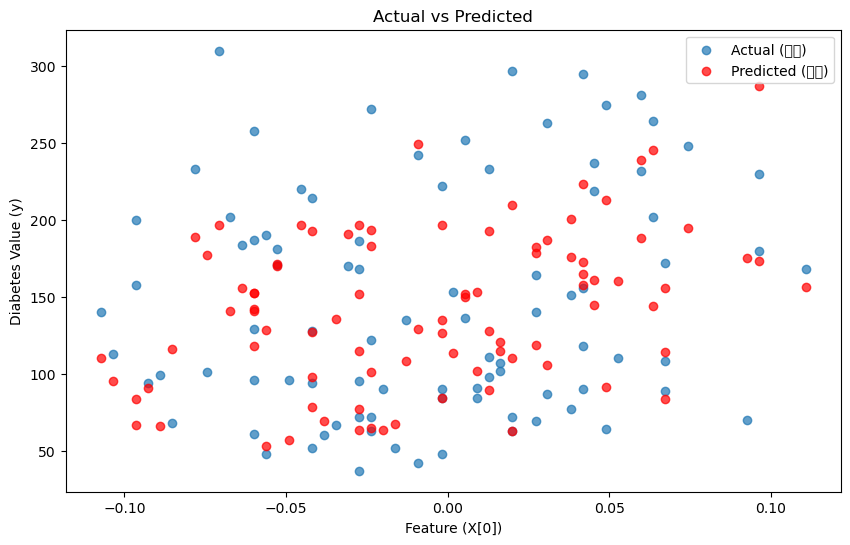

In [17]:
import matplotlib.pyplot as plt

# 1. 그래프 크기를 설정합니다.
plt.figure(figsize=(10, 6))

# 2. 실제 정답 데이터(y_test) 시각화
# x축: 테스트 데이터의 첫 번째 컬럼 (나이 혹은 지표 중 하나)
# y축: 실제 당뇨병 수치
# 파란색 점으로 표시합니다.
plt.scatter(X_test[:, 0], y_test, label="Actual (정답)", alpha=0.7)

# 3. 모델의 예측 데이터(prediction) 시각화
# 동일한 x축에 모델이 예측한 값을 빨간색 점으로 겹쳐서 그립니다.
plt.scatter(X_test[:, 0], prediction, label="Predicted (예측)", color='red', alpha=0.7)

# 4. 그래프의 가독성을 높이기 위한 설정
plt.xlabel('Feature (X[0])')       # x축 이름: 첫 번째 특성
plt.ylabel('Diabetes Value (y)')   # y축 이름: 당뇨병 수치
plt.title('Actual vs Predicted')   # 그래프 제목
plt.legend()                       # 범례 표시 (어느 게 정답이고 예측인지 구분)

# 5. 최종 출력
plt.show()

# 프로젝트 2 : 날씨 좋은 월요일 오후 세 시, 자전거 타는 사람은 몇 명?

In [18]:
import pandas as pd

# 1. 캐글(Kaggle)에서 제공하는 자전거 대여 수요 데이터를 불러옵니다.
# 경로: ~/data/data/bike-sharing-demand/train.csv
train = pd.read_csv("~/data/data/bike-sharing-demand/train.csv") 

# 2. 데이터의 기본 정보를 확인합니다. (매우 중요!)
# - 각 컬럼(특징)들이 어떤 데이터 타입(숫자인지, 문자인지)인지 확인합니다.
# - 결측치(Non-Null Count)가 있는지 체크합니다.
train.info()

# 3. 데이터의 상위 5줄을 미리 봅니다. (데이터의 생김새 파악)
train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [19]:
train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  minute      10886 non-

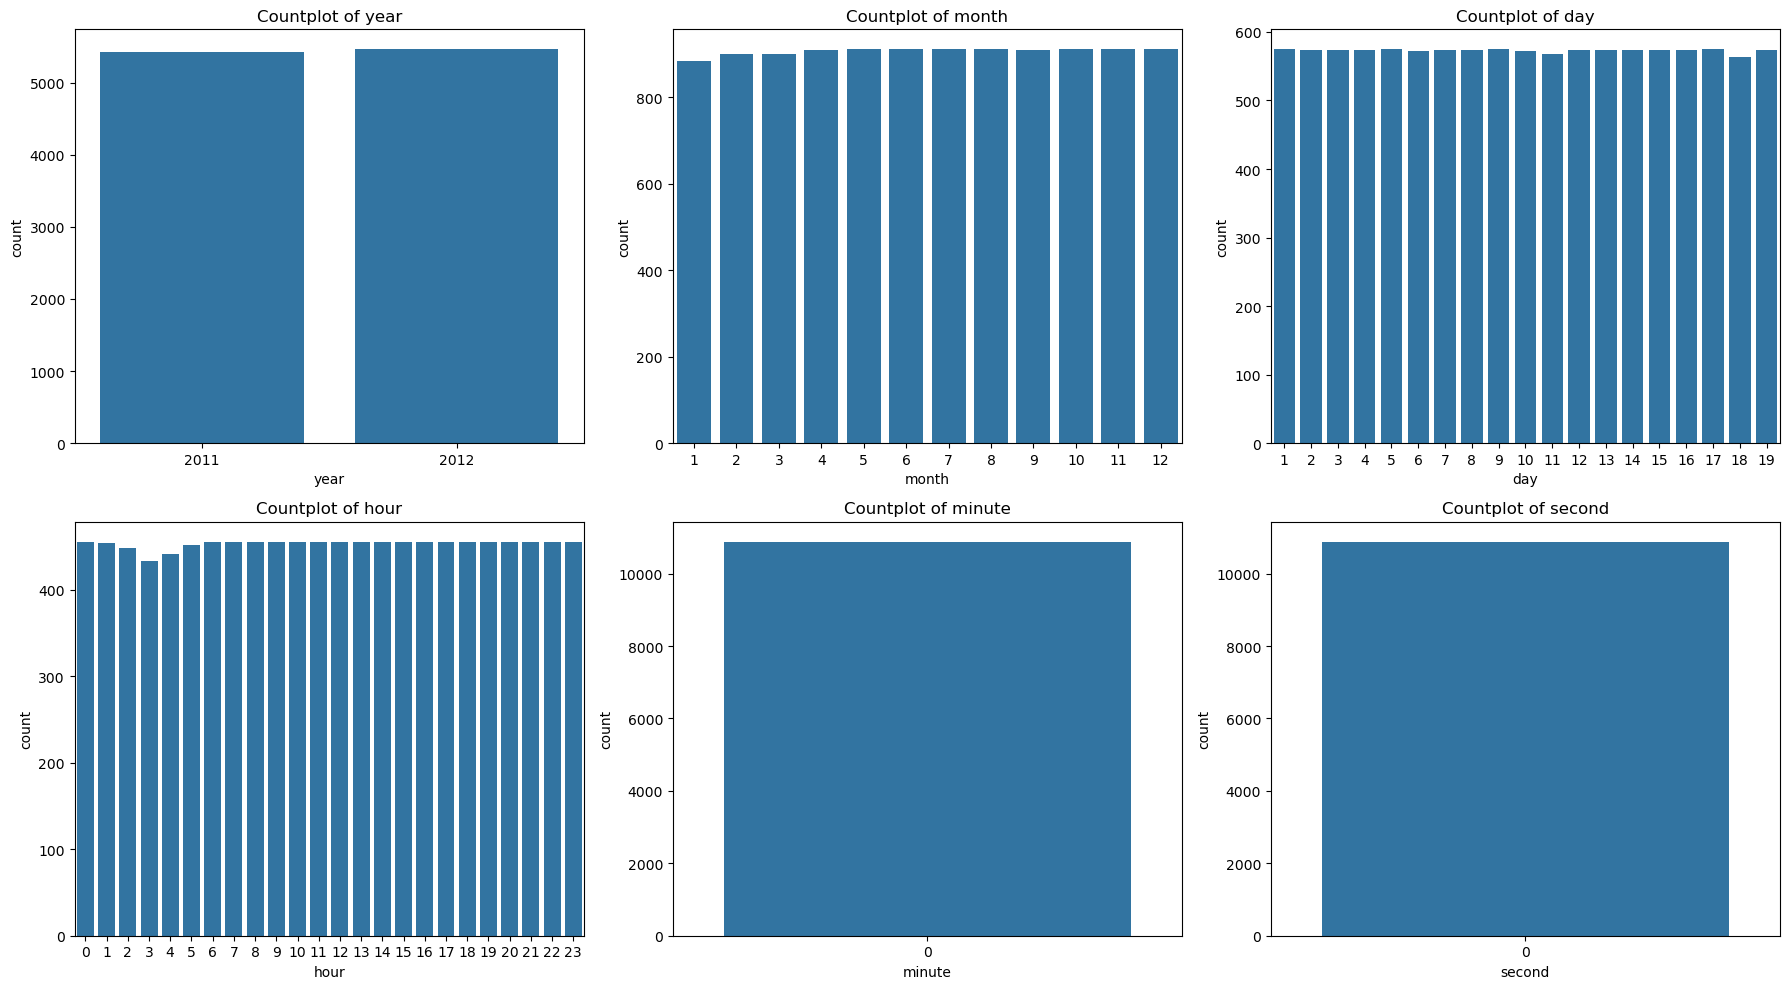

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 2행 3열의 레이아웃을 만들어 6개의 그래프를 한 화면에 배치합니다.
# figsize=(18, 10)으로 설정하여 그래프들이 겹치지 않고 시원하게 보이도록 하셨네요!
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# 2. 반복문(for)을 사용하여 코드를 효율적으로 작성하셨습니다. (아주 영리한 구현입니다!)
cols = ['year', 'month', 'day', 'hour', 'minute', 'second']
for ax, col in zip(axs.flatten(), cols):
    # sns.countplot: 각 범주별 데이터가 몇 개씩 있는지 막대그래프로 보여줍니다.
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(f'Countplot of {col}')

# 3. 레이아웃이 겹치지 않게 조절하고 화면에 출력합니다.
plt.tight_layout()
plt.show()

In [21]:
# 1. 모델이 학습할 특징(X)들을 선택합니다. 
# - 'year', 'month', 'day', 'hour': 우리가 datetime에서 정성껏 뽑아낸 시간 정보들입니다.
# - 'temp', 'humidity', 'windspeed': 날씨 정보는 자전거 대여량에 직결됩니다.
# - 'minute', 'second': 모든 값이 0이므로 학습에 방해만 되어 뺀 것은 아주 잘한 선택입니다!
features = ['year', 'month', 'day', 'hour', 'temp', 'humidity', 'windspeed']
X = train[features]

# 2. 모델이 맞춰야 할 정답(y)을 선택합니다.
y = train['count']

# 3. 사이킷런의 train_test_split으로 데이터를 8:2 비율로 나눕니다.
# random_state=42를 주어 결과의 재현성을 확보합니다. (평가 시 동일한 결과 도출을 위해 필수!)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 잘 나뉘었는지 크기를 확인합니다.
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(8708, 7) (8708,)
(2178, 7) (2178,)


In [22]:
from sklearn.linear_model import LinearRegression

# 1. 사이킷런의 선형 회귀(Linear Regression) 모델을 불러옵니다.
# 우리가 직접 구현했던 가중치(W)와 편향(b)을 내부적으로 아주 빠르게 최적화해주는 도구입니다.
model = LinearRegression()

# 2. 준비된 학습 데이터(X_train, y_train)를 모델에게 공부시킵니다.
# .fit() 함수는 입력 데이터와 정답 사이의 선형 관계(패턴)를 찾아냅니다.
# 내부적으로 MSE를 최소화하는 방향으로 가중치들을 계산하여 저장합니다.
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. 학습된 모델에 테스트 데이터(X_test)를 입력하여 예측값(y_pred)을 생성합니다.
y_pred = model.predict(X_test)

# 2. MSE(Mean Squared Error)를 계산합니다.
mse = mean_squared_error(y_test, y_pred)

# 3. RMSE(Root Mean Squared Error)를 계산합니다. (평가기준의 핵심!)
# MSE에 루트를 씌워 실제 대여량(count) 단위와 맞춘 지표입니다.
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 19961.901814435438
RMSE: 141.2865946027274


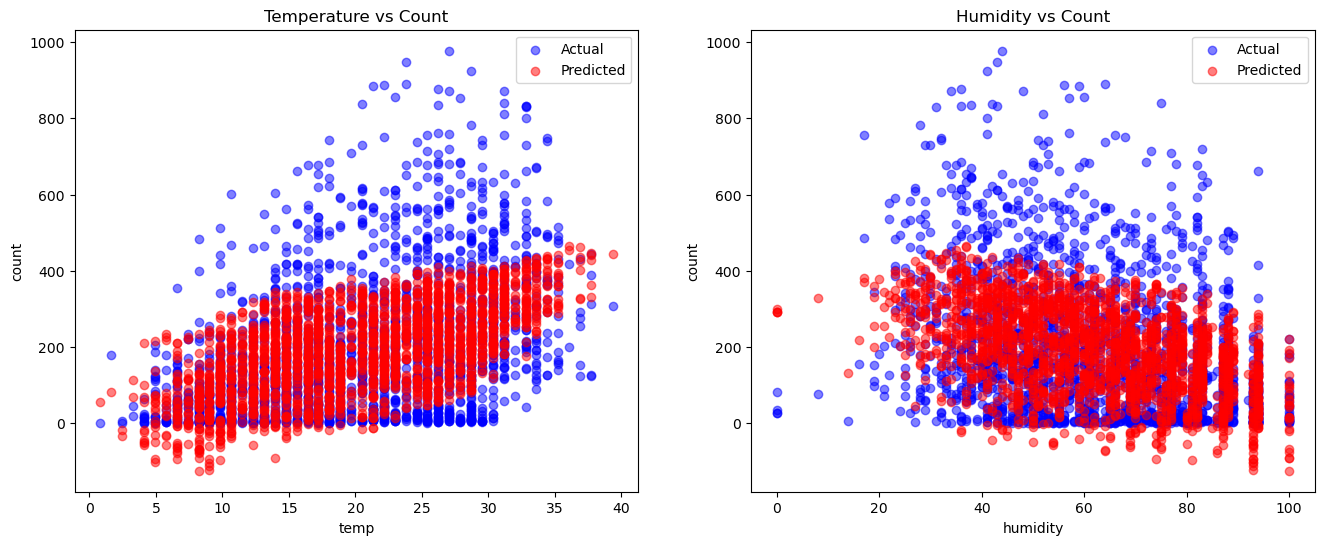

In [24]:
# 1. 두 개의 그래프를 나란히 배치하기 위해 1행 2열의 subplots를 생성합니다.
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# --- [그래프 1: 온도(temp) vs 대여량(count)] ---
# 파란색 점: 실제 정답 (y_test)
# 빨간색 점: 모델의 예측값 (y_pred) -> alpha=0.5로 투명도를 주어 겹치는 부분을 확인하기 쉽게 하셨네요!
axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual', alpha=0.5)
axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# --- [그래프 2: 습도(humidity) vs 대여량(count)] ---
axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual', alpha=0.5)
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()

plt.show()